<a href="https://colab.research.google.com/github/Utkarshparker/utkarsh-salary_predictot/blob/main/salary_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle

In [10]:
!kaggle datasets download -d jamiewelsh2/nba-player-salaries-2022-23-season

Dataset URL: https://www.kaggle.com/datasets/jamiewelsh2/nba-player-salaries-2022-23-season
License(s): ODC Attribution License (ODC-By)
  0% 0.00/72.6k [00:00<?, ?B/s]
100% 72.6k/72.6k [00:00<00:00, 246MB/s]


In [11]:
import zipfile
zip_ref = zipfile.ZipFile('/content/nba-player-salaries-2022-23-season.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [12]:
import pandas as pd
df = pd.read_csv("/content/nba_salaries.csv")
df.head()

,Unnamed: 0,Player Name,Salary,Position,Age,Team,GP,GS,MP,FG,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Player-additional
0,0,Stephen Curry,48070014,PG,34,GSW,56,56,34.7,10.0,...,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,curryst01
1,1,John Wall,47345760,PG,32,LAC,34,3,22.2,4.1,...,0.4,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,walljo01
2,2,Russell Westbrook,47080179,PG,34,LAL/LAC,73,24,29.1,5.9,...,1.2,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,westbru01
3,3,LeBron James,44474988,PF,38,LAL,55,54,35.5,11.1,...,1.2,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,jamesle01
4,4,Kevin Durant,44119845,PF,34,BRK/PHO,47,47,35.6,10.3,...,0.4,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,duranke01


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("nba_salaries.csv")
df.head()

,Unnamed: 0,Player Name,Salary,Position,Age,Team,GP,GS,MP,FG,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Player-additional
0,0,Stephen Curry,48070014,PG,34,GSW,56,56,34.7,10.0,...,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,curryst01
1,1,John Wall,47345760,PG,32,LAC,34,3,22.2,4.1,...,0.4,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,walljo01
2,2,Russell Westbrook,47080179,PG,34,LAL/LAC,73,24,29.1,5.9,...,1.2,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,westbru01
3,3,LeBron James,44474988,PF,38,LAL,55,54,35.5,11.1,...,1.2,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,jamesle01
4,4,Kevin Durant,44119845,PF,34,BRK/PHO,47,47,35.6,10.3,...,0.4,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,duranke01


In [14]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 467 entries, 0 to 466
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         467 non-null    int64  
 1   Player Name        467 non-null    object 
 2   Salary             467 non-null    int64  
 3   Position           467 non-null    object 
 4   Age                467 non-null    int64  
 5   Team               467 non-null    object 
 6   GP                 467 non-null    int64  
 7   GS                 467 non-null    int64  
 8   MP                 467 non-null    float64
 9   FG                 467 non-null    float64
 10  FGA                467 non-null    float64
 11  FG%                466 non-null    float64
 12  3P                 467 non-null    float64
 13  3PA                467 non-null    float64
 14  3P%                454 non-null    float64
 15  2P                 467 non-null    float64
 16  2PA                467 non

,Unnamed: 0,Salary,Age,GP,GS,MP,FG,FGA,FG%,3P,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
count,467.000000,4.670000e+02,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,466.000000,467.000000,...,444.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000
mean,233.000000,8.416599e+06,25.820128,48.233405,22.650964,19.871306,3.351392,7.117773,0.465009,0.996574,...,0.753489,0.866809,2.662099,3.528051,2.107709,0.610493,0.379015,1.114133,1.702784,9.129979
std,134.955548,1.070812e+07,4.275113,24.807740,27.094577,9.548684,2.457836,5.020700,0.109547,0.880468,...,0.148659,0.746976,1.707984,2.277160,1.957517,0.399083,0.364387,0.830051,0.776957,6.906006
min,0.000000,5.849000e+03,19.000000,1.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,116.500000,1.782621e+06,23.000000,31.000000,1.000000,12.500000,1.600000,3.300000,0.417000,0.300000,...,0.691000,0.400000,1.400000,1.900000,0.800000,0.300000,0.100000,0.500000,1.200000,4.100000
50%,233.000000,3.722040e+06,25.000000,55.000000,8.000000,19.200000,2.700000,5.800000,0.455000,0.800000,...,0.769000,0.700000,2.300000,3.000000,1.400000,0.600000,0.300000,0.900000,1.700000,7.100000
75%,349.500000,1.063354e+07,29.000000,68.500000,45.500000,28.300000,4.300000,9.400000,0.507500,1.500000,...,0.844000,1.100000,3.500000,4.500000,2.900000,0.800000,0.500000,1.500000,2.200000,11.700000
max,466.000000,4.807001e+07,42.000000,83.000000,83.000000,41.000000,11.200000,22.200000,1.000000,4.900000,...,1.000000,5.100000,9.600000,12.500000,10.700000,3.000000,2.500000,4.100000,5.000000,33.100000


In [17]:
df.isnull().sum()

,0
Player Name,0
Salary,0
Position,0
Age,0
Team,0
GP,0
GS,0
MP,0
FG,0
FGA,0


In [18]:
df.sort_values("Salary", ascending=False).head(10)

,Player Name,Salary,Position,Age,Team,GP,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Player-additional
0,Stephen Curry,48070014,PG,34,GSW,56,56,34.7,10.0,20.2,...,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,curryst01
1,John Wall,47345760,PG,32,LAC,34,3,22.2,4.1,9.9,...,0.4,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,walljo01
2,Russell Westbrook,47080179,PG,34,LAL/LAC,73,24,29.1,5.9,13.6,...,1.2,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,westbru01
3,LeBron James,44474988,PF,38,LAL,55,54,35.5,11.1,22.2,...,1.2,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,jamesle01
4,Kevin Durant,44119845,PF,34,BRK/PHO,47,47,35.6,10.3,18.3,...,0.4,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,duranke01
5,Bradley Beal,43279250,SG,29,WAS,50,50,33.5,8.9,17.6,...,0.8,3.1,3.9,5.4,0.9,0.7,2.9,2.1,23.2,bealbr01
9,Damian Lillard,42492492,PG,32,POR,58,58,36.3,9.6,20.7,...,0.8,4.0,4.8,7.3,0.9,0.3,3.3,1.9,32.2,lillada01
8,Giannis Antetokounmpo,42492492,PF,28,MIL,63,63,32.1,11.2,20.3,...,2.2,9.6,11.8,5.7,0.8,0.8,3.9,3.1,31.1,antetgi01
7,Paul George,42492492,SF,32,LAC,56,56,34.6,8.2,17.9,...,0.8,5.3,6.1,5.1,1.5,0.4,3.1,2.8,23.8,georgpa01
6,Kawhi Leonard,42492492,SF,31,LAC,52,50,33.6,8.6,16.8,...,1.1,5.4,6.5,3.9,1.4,0.5,1.7,1.6,23.8,leonaka01


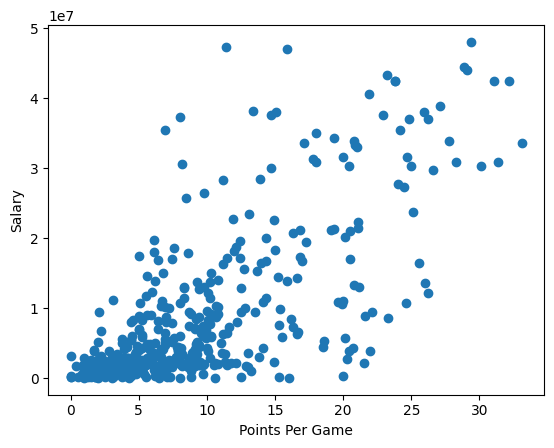

In [24]:
import matplotlib.pyplot as plt
plt.scatter(df["PTS"], df["Salary"])
plt.xlabel("Points Per Game")
plt.ylabel("Salary")
plt.show()

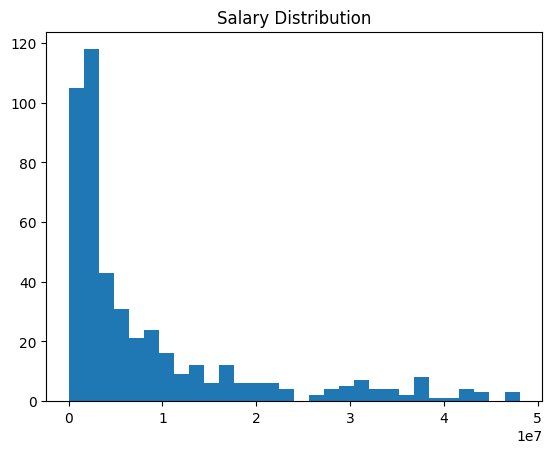

In [25]:
import matplotlib.pyplot as plt
plt.hist(df["Salary"], bins=30)
plt.title("Salary Distribution")
plt.show()

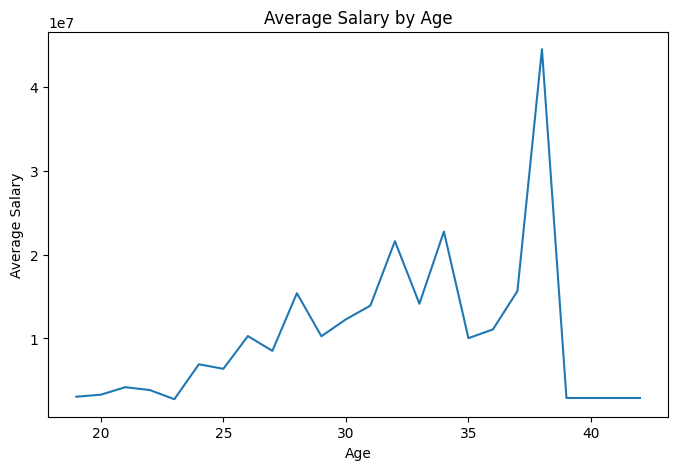

In [27]:
avg_salary_age = df.groupby("Age")["Salary"].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_salary_age)
plt.title("Average Salary by Age")
plt.xlabel("Age")
plt.ylabel("Average Salary")
plt.show()

In [28]:
young = df[df["Age"] < 25]["Salary"].mean()
veteran = df[df["Age"] >= 25]["Salary"].mean()

print("Average Salary (Young Players):", young)
print("Average Salary (Veterans):", veteran)

Average Salary (Young Players): 4182133.153846154
Average Salary (Veterans): 11817250.652509652


In [29]:
df["StarScore"] = df["PTS"] + df["AST"] + df["TRB"]

stars = df[df["StarScore"] > df["StarScore"].mean()]
role_players = df[df["StarScore"] <= df["StarScore"].mean()]

print("Average Salary of Star Players:", stars["Salary"].mean())
print("Average Salary of Role Players:", role_players["Salary"].mean())

Average Salary of Star Players: 15609929.931578947
Average Salary of Role Players: 3482544.866425993


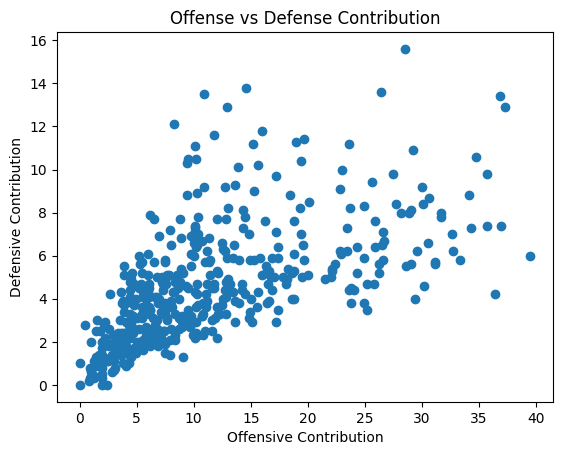

In [31]:
df["Offense"] = df["PTS"] + df["AST"]
df["Defense"] = df["STL"] + df["BLK"] + df["TRB"]

plt.scatter(df["Offense"], df["Defense"])
plt.xlabel("Offensive Contribution")
plt.ylabel("Defensive Contribution")
plt.title("Offense vs Defense Contribution")
plt.show()